# 第 12 章 · 表征搜索与退火代码实验

[章节网页](../ch12.html)

## 运行内容

- 使用 scipy dual_annealing
- 记录候选 loss
- 绘制搜索轨迹

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 使用 scipy dual_annealing 搜索二维表征，使目标函数尽量小。
def objective(vec):
    x, y = vec
    return (x - 1.4) ** 2 + (y + 0.6) ** 2 + 0.35 * np.sin(4 * x) * np.cos(3 * y)

anneal_trace = []

def collect_state(x, f, context):
    anneal_trace.append({"候选x": x[0], "候选y": x[1], "loss": f, "context": context})

result = dual_annealing(objective, bounds=[(-3, 3), (-3, 3)], maxiter=35, seed=3, callback=collect_state)
anneal_df = pd.DataFrame(anneal_trace)
if anneal_df.empty:
    anneal_df = pd.DataFrame([{"候选x": result.x[0], "候选y": result.x[1], "loss": result.fun, "context": 0}])

display(anneal_df.tail(8).round(4))
print("best:", np.round(result.x, 4), "loss:", round(float(result.fun), 4))

,候选x,候选y,loss,context
0,2.3765,0.6255,2.4639,0
1,0.6755,0.6255,1.9818,0
2,1.2521,-0.2537,-0.1006,1


best: [ 1.2521 -0.2537] loss: -0.1006


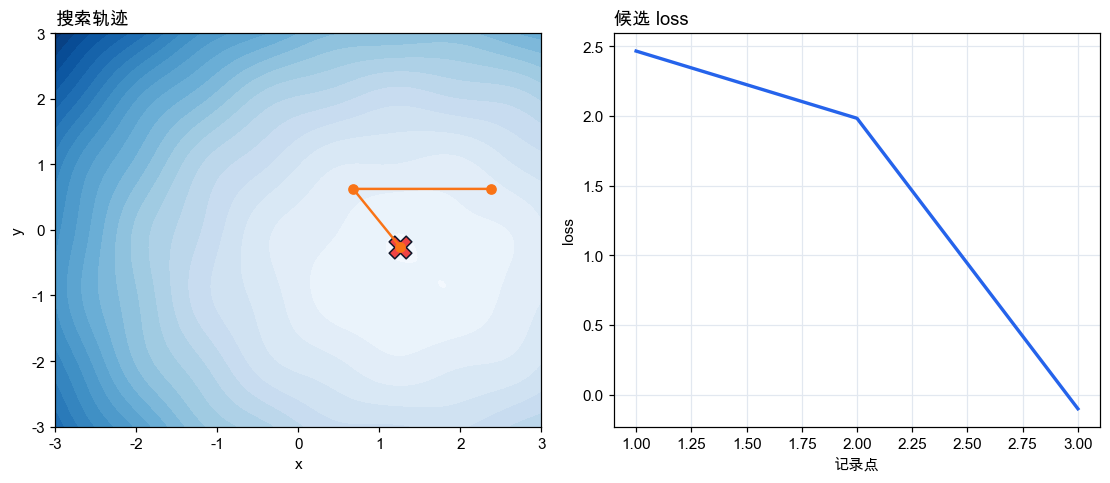

In [3]:
# 绘制搜索轨迹和 loss。
grid_x = np.linspace(-3, 3, 120)
grid_y = np.linspace(-3, 3, 120)
xx, yy = np.meshgrid(grid_x, grid_y)
zz = objective([xx, yy])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.5))
axes[0].contourf(xx, yy, zz, levels=24, cmap="Blues")
axes[0].plot(anneal_df["候选x"], anneal_df["候选y"], color="#f97316", marker="o", linewidth=1.6)
axes[0].scatter(result.x[0], result.x[1], marker="X", s=220, color="#ef4444", edgecolor="#0f172a")
axes[0].set_title("搜索轨迹", loc="left", fontweight="bold")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].plot(range(1, len(anneal_df) + 1), anneal_df["loss"], color="#2563eb", linewidth=2.2)
axes[1].set_title("候选 loss", loc="left", fontweight="bold")
axes[1].set_xlabel("记录点")
axes[1].set_ylabel("loss")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()